<a href="https://www.kaggle.com/code/emmglezz/mars-crater-detection?scriptVersionId=316743280" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Mars Crater Detection with YOLOv8

This project trains a computer vision model to automatically detect impact craters 
on the surface of Mars using satellite imagery from NASA.

The dataset consists of labeled Mars and lunar surface images in YOLO format, 
sourced from the Martian/Lunar Crater Detection Dataset on Kaggle. I fine-tuned 
a YOLOv8 nano model on this data with the goal of deploying it as an interactive web app 
where anyone can upload a Mars image and get crater detections in real time.

**Model:** YOLOv8n (fine-tuned)  
**Dataset:** 143 labeled Mars/lunar images  
**Task:** Object detection — locating and bounding impact craters  
**Final mAP50:** 0.703

## Data Exploration

Before training, I loaded a sample image from the dataset and visualize it alongside 
its ground truth labels. Each crater is annotated in YOLO format: 
class, x_center, y_center, width, height — all normalized between 0 and 1 relative 
to image dimensions. I converted these to pixel coordinates and draw bounding boxes 
to verify the labels align correctly with the craters in the image.

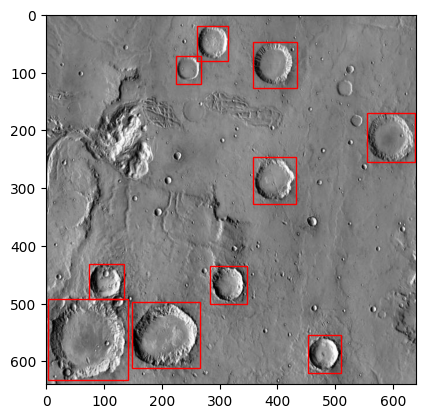

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg

train_path = '/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/train'
img_path = train_path + '/images/011_png.rf.8ac312b4898f0106d10b76952a55d237.jpg'
img = mpimg.imread(img_path)

img_height, img_width = img.shape[:2]

fig, ax = plt.subplots()

ax.imshow(img)

with open(train_path + '/labels/011_png.rf.8ac312b4898f0106d10b76952a55d237.txt', 'r') as file:
    for line in file:
        arr = line.split()
        x_center = float(arr[1])
        y_center = float(arr[2])
        width = float(arr[3])
        height = float(arr[4])

        box_width = width * img_width
        box_height = height * img_height

        x_top_left = (x_center - width/2) * img_width
        y_top_left = (y_center - height/2) * img_height
        
        rect = patches.Rectangle((x_top_left, y_top_left), box_width, box_height, linewidth=1, edgecolor='red', fill=False)
        ax.add_patch(rect)

plt.show()

## Dataset Configuration

YOLOv8 requires a YAML configuration file that defines the paths to the train, validation, and test image folders, along with the number of classes and their names. Since the dataset didn't include one, I created it manually. This dataset has a single class: crater.

In [2]:
import yaml

data = {
    'train': '/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/train/images',
    'val': '/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/valid/images',
    'test': '/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/test/images',
    'nc': 1,
    'names': ['crater']
}

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data, f)

## Model Training

I fine-tuned a pretrained YOLOv8 nano model on the crater dataset for 50 epochs at 640x640 resolution. Rather than training from scratch, fine-tuning starts from weights already learned on a large dataset, which works significantly better when the training data is small. The best weights are automatically saved during training based on validation performance.

In [3]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='/kaggle/working/data.yaml',
    epochs=50,
    imgsz=640
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x799078fff440>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## Inference on Test Image

Running the trained model on an unseen test image to verify it generalizes beyond the training data. The model outputs bounding boxes with confidence scores for each detected crater. Each detection shows the label "crater" followed by the confidence score, indicating how certain the model is about that particular detection.


image 1/1 /kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/test/images/mars_crater--97-_jpg.rf.63347c2ec963cf5c4ab641e1ba872df1.jpg: 640x640 5 craters, 149.4ms
Speed: 2.1ms preprocess, 149.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


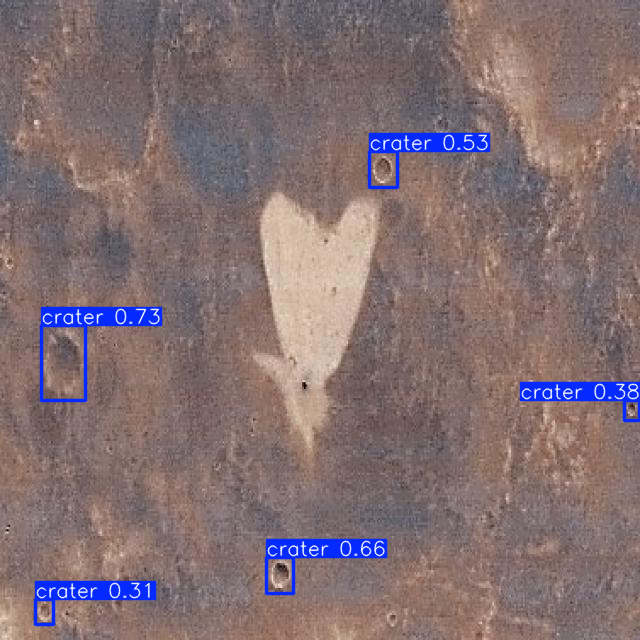

In [4]:
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

results = model('/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/test/images/mars_crater--97-_jpg.rf.63347c2ec963cf5c4ab641e1ba872df1.jpg')

results[0].show()